# Notebook for testing aspects of the Diffusers library
Current list of sections:
1. VAE

## VAE

/media/aris/Data/master2025dev/aris_master/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


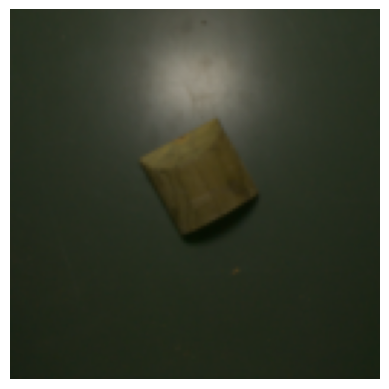

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0070373416..0.60370684].


Latents shape: torch.Size([1, 4, 16, 16])
Reconstructed image shape: torch.Size([1, 3, 128, 128])


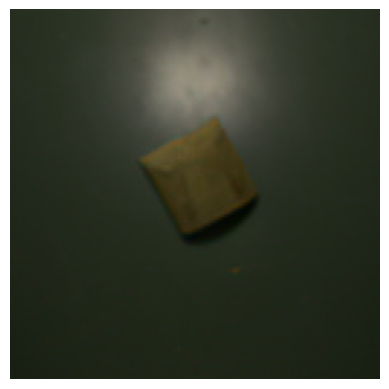

In [1]:
# Change working directory to parent directory
import os
os.chdir("/media/aris/Data/master2025dev/aris_master")
device = "cuda"
from diffusers import AutoencoderKL

# ----------- Download model from Hugging Face and save it locally ----------- #
"""
# url = "https://huggingface.co/stabilityai/sd-vae-ft-mse-original/blob/main/vae-ft-mse-840000-ema-pruned.safetensors"  # can also be a local file
# model = AutoencoderKL.from_single_file(url)
# Save the model to current working directory
# save_path = os.path.join(os.getcwd(), "models/VAE/vae-ft-mse-840000-ema-pruned")
# model.save_pretrained(save_path)

# Print files in the specified directory
# vae_directory = os.path.join(os.getcwd(), "models/VAE/")
# print("Files in VAE directory:", os.listdir(vae_directory))
"""

# # --------------------------- import model locally --------------------------- #
local_model_path = os.path.join(os.getcwd(), "models/VAE/vae-ft-mse-840000-ema-pruned")
vae = AutoencoderKL.from_pretrained(local_model_path)
vae.to(device)

# # Test the model by printing its configuration
# print("Model configuration:", model.config)

# Test the model with image
img_path = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories_512x512/train/impregnated_wood/images/img_bold-eagle_2024-11-04T16-33-09-968.png"
from PIL import Image
image = Image.open(img_path).convert("RGB")

#convert image to tensor
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
image = transform(image).unsqueeze(0).to(device)

#save
save_path = "/media/aris/Data/master2025dev/outputs/visualizations/VAE_half_res_test_input.png"
#Limit image to valid range and convert to PIL
img = (image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
img = transforms.ToPILImage()(img)
img.save(save_path)


# plot image 
import matplotlib.pyplot as plt
plt.imshow((image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5))
plt.axis('off')
plt.show()
# latents = model.encode(image)


# ---------------------------------- encode ---------------------------------- #
import torch    
with torch.no_grad():
    latents = vae.encode(image).latent_dist.sample()
print("Latents shape:", latents.shape)

# ---------------------------------- decode ---------------------------------- #
with torch.no_grad():
    reconstructed_image = vae.decode(latents).sample
    
print("Reconstructed image shape:", reconstructed_image.shape)
# plot reconstructed image
plt.imshow((reconstructed_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5))
plt.axis('off')
plt.show()

#save
save_path = "/media/aris/Data/master2025dev/outputs/visualizations/VAE_half_res_test_output.png"
#Limit image to valid range and convert to PIL
img = (reconstructed_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
reconstructed_image_pil = transforms.ToPILImage()(img)
reconstructed_image_pil.save(save_path)






#vae.to("cpu")




## Debugging attempt of the green hue of the VAE
I suspect the green hue of the vae could come from the transform in the dataloader. Following code takes the dataloader and visualises the vae input-output

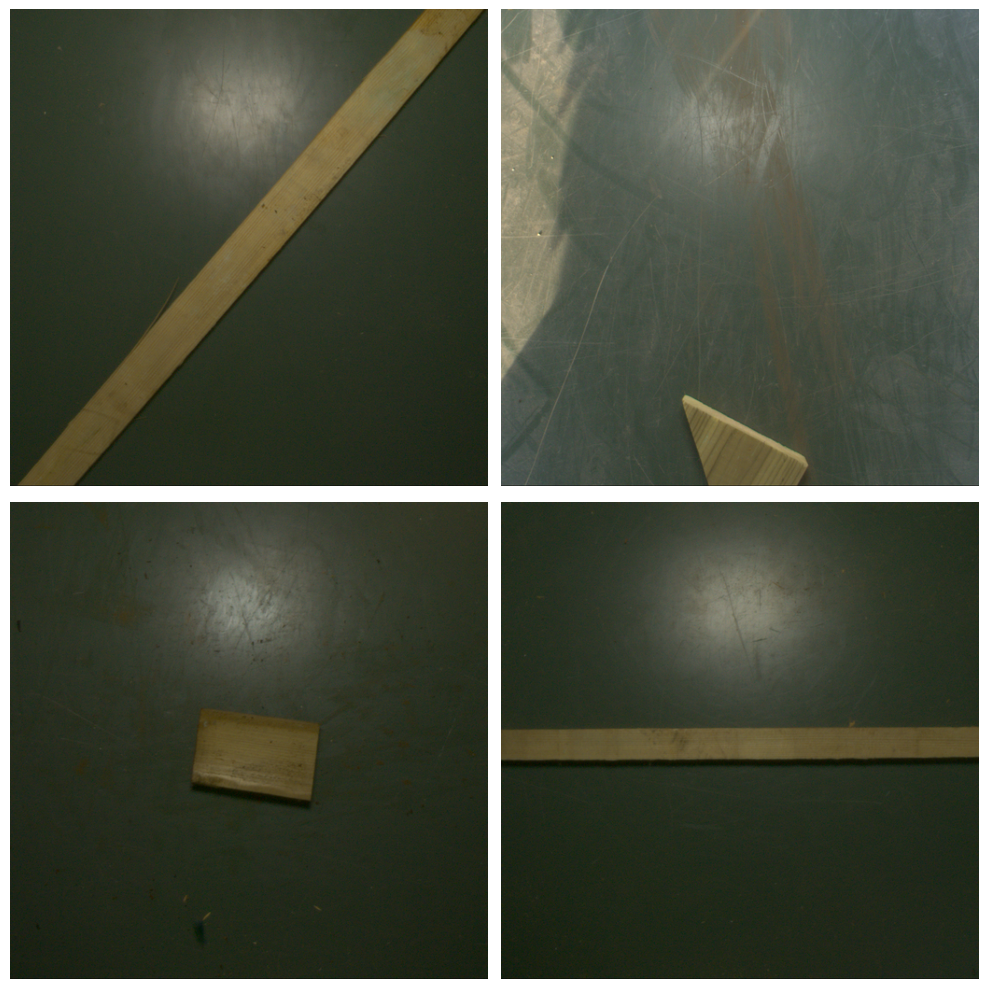

In [2]:
resolution = (512, 512)
center_crop = True
random_flip = True
preserve_input_precision = False
train_batch_size = 4
dataloader_num_workers = 4
dataset_dir = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories_512x512/train/impregnated_wood/images/"

import torch
from torchvision import transforms
import matplotlib.pyplot as plt
def _ensure_three_channels(tensor: torch.Tensor) -> torch.Tensor:
    """
    Ensure the tensor has exactly three channels (C, H, W) by repeating or truncating channels when needed.
    """
    if tensor.ndim == 2:
        tensor = tensor.unsqueeze(0)
    channels = tensor.shape[0]
    if channels == 3:
        return tensor
    if channels == 1:
        return tensor.repeat(3, 1, 1)
    if channels == 2:
        return torch.cat([tensor, tensor[:1]], dim=0)
    if channels > 3:
        return tensor[:3]
    raise ValueError(f"Unsupported number of channels: {channels}")

import numpy as np
def preview_dataloader(dataloader, num_images=8):
    """
    Preview images from the dataloader in a grid.
    
    Args:
        dataloader: PyTorch DataLoader object
        num_images: Number of images to display (default: 8)
    """
    # Get a batch from the dataloader
    batch = next(iter(dataloader))
    images = batch["input"]
    
    # Limit to num_images
    images = images[:num_images]
    
    # Denormalize images from [-1, 1] to [0, 1]
    images = (images + 1) / 2
    images = torch.clamp(images, 0, 1)
    
    # Create grid
    grid_size = int(np.ceil(np.sqrt(num_images)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    axes = axes.flatten()
    
    for idx, ax in enumerate(axes):
        if idx < len(images):
            # Convert to numpy and transpose from CxHxW to HxWxC
            img = images[idx].permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Preprocessing the datasets and DataLoaders creation.
spatial_augmentations = [
    transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(resolution) if center_crop else transforms.RandomCrop(resolution),
    transforms.RandomHorizontalFlip() if random_flip else transforms.Lambda(lambda x: x),
]

augmentations = transforms.Compose(
    spatial_augmentations
    + [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

precision_augmentations = transforms.Compose(
    [
        transforms.PILToTensor(),
        transforms.Lambda(_ensure_three_channels),
        transforms.ConvertImageDtype(torch.float32),
    ]
    + spatial_augmentations
    + [transforms.Normalize([0.5], [0.5])]
)

def transform_images(examples):
    processed = []
    for image in examples["image"]:
        if not preserve_input_precision:
            processed.append(augmentations(image.convert("RGB")))
        else:
            precise_image = image
            if precise_image.mode == "P":
                precise_image = precise_image.convert("RGB")
            processed.append(precision_augmentations(precise_image))
    return {"input": processed}

from datasets import load_dataset
# Load the dataset
dataset = load_dataset("imagefolder", data_dir=dataset_dir, split="train")
    

dataset.set_transform(transform_images)
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=train_batch_size, shuffle=True, num_workers=dataloader_num_workers
)
preview_dataloader(train_dataloader, num_images=4)






In [3]:
from diffusers import AutoencoderKL
local_model_path = "/media/aris/Data/master2025dev/aris_master/models/VAE/vae-ft-mse-840000-ema-pruned"
vae = AutoencoderKL.from_pretrained(local_model_path)
vae.to("cuda")

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

Test images shape: torch.Size([4, 3, 512, 512]), Test images min: -1.0, Test images max: 0.4745098352432251, Test images dtype: torch.float32
Latent shape: torch.Size([4, 4, 64, 64]), Latent min: -60.09041213989258, Latent max: 42.89801788330078, Latent dtype: torch.float32
Latents shape after scaling: torch.Size([4, 4, 64, 64]), Latent min: -10.94546890258789, Latent max: 7.813874244689941, Latent dtype: torch.float32


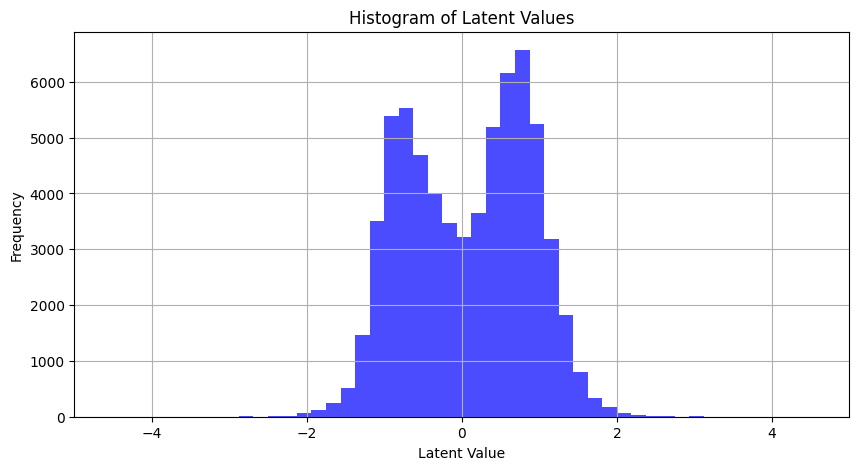

In [35]:
# ---------------------------------- ENCODE ---------------------------------- #
#check for image dimensions
test_batch = next(iter(train_dataloader))
test_images = test_batch["input"].to("cuda")

print(f"Test images shape: {test_images.shape}, Test images min: {test_images.min().item()}, Test images max: {test_images.max().item()}, Test images dtype: {test_images.dtype}")

with torch.no_grad():
    latent_dist = vae.encode(test_images).latent_dist
    latents = latent_dist.sample()
print(f"Latent shape: {latents.shape}, Latent min: {latents.min().item()}, Latent max: {latents.max().item()}, Latent dtype: {latents.dtype}")
latents = latents * vae.config.scaling_factor
print(f"Latents shape after scaling: {latents.shape}, Latent min: {latents.min().item()}, Latent max: {latents.max().item()}, Latent dtype: {latents.dtype}")


# ------------------------- PLOT HISTOGAM OF LATENTS ------------------------- #
import matplotlib.pyplot as plt
import numpy as np
# Flatten the latents to 1D
latents_flat = latents.cpu().numpy().flatten()
# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(latents_flat, bins=100, color='blue', alpha=0.7)
plt.title('Histogram of Latent Values')
plt.xlabel('Latent Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.xlim(-5, 5)  # Set x-axis limits to focus on the range of interest
plt.show()

Test images shape: torch.Size([4, 3, 512, 512]), Test images min: -1.0, Test images max: 0.7019608020782471, Test images dtype: torch.float32
Input image shape: torch.Size([4, 3, 512, 512]), Latent shape: torch.Size([4, 4, 64, 64]), Latent min: -61.5365104675293, Latent max: 44.163333892822266, Latent dtype: torch.float32
Latents shape after scaling: torch.Size([4, 4, 64, 64]), Latent min: -0.37189507484436035, Latent max: 0.26690053939819336, Latent dtype: torch.float32
Latents shape: torch.Size([4, 4, 64, 64])
batch shape: torch.Size([4, 4, 64, 64])
Final decoded images shape: torch.Size([4, 3, 512, 512])


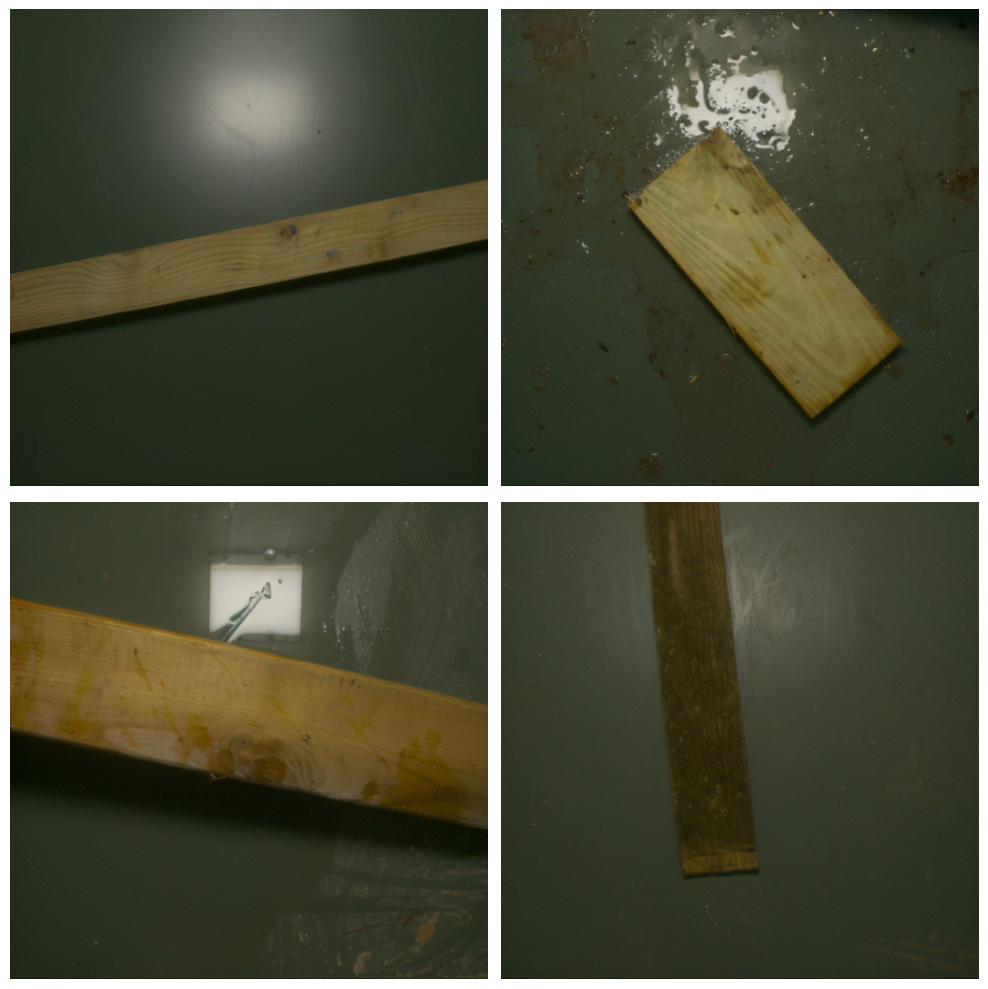

In [29]:



# ---------------------------------- Decode ---------------------------------- #
print("Latents shape:", latents.shape)
# decode the latents with VAE in smaller batches to avoid OOM
decoded_images = []
vae_batch_size = 4  # Process 4 images at a time
with torch.no_grad():
    for i in range(0, len(latents), vae_batch_size):
        batch = latents[i:i+vae_batch_size] / vae.config.scaling_factor / vae.config.scaling_factor / vae.config.scaling_factor
        
        if not isinstance(batch, torch.Tensor):
            batch = torch.from_numpy(batch)
        # batch = batch.permute(0, 3, 1, 2).contiguous()
        print("batch shape:", batch.shape)
        decoded_batch = vae.decode(batch.to(vae.device), return_dict=False)[0]
        decoded_images.append(decoded_batch.cpu())
        del batch, decoded_batch
        torch.cuda.empty_cache()
images = torch.cat(decoded_images, dim=0)
print("Final decoded images shape:", images.shape)

#Plot decoded images
# Limit to num_images
num_images = 4
images = images[:num_images]

# Denormalize images from [-1, 1] to [0, 1]
images = (images + 1) / 2
images = torch.clamp(images, 0, 1)

# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(images):
        # Convert to numpy and transpose from CxHxW to HxWxC
        img = images[idx].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

Warped latents shape: torch.Size([4, 4, 64, 64]) Warped latents min: 0.0 Warped latents max: 1.0 Warped latents dtype: torch.float32
Warped images shape: torch.Size([4, 3, 512, 512]) Warped images min: -0.4589645564556122 Warped images max: 0.4200458228588104 Warped images dtype: torch.float32


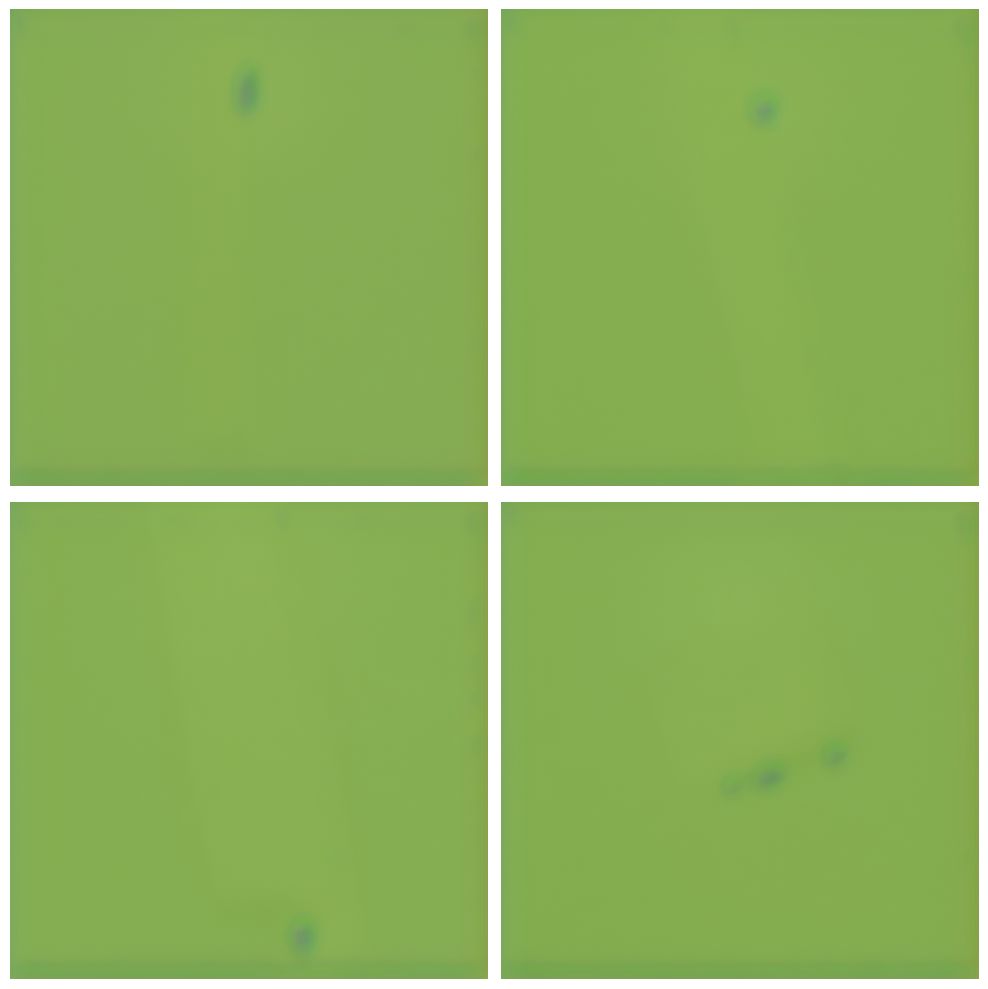

In [12]:
## Warped latents:
# map the latents to the range [0-1] from [-12,12]
warped_latents = (latents - latents.min()) / (latents.max() - latents.min())
# warped_latents = latents



print("Warped latents shape:", warped_latents.shape, "Warped latents min:", warped_latents.min().item(), "Warped latents max:", warped_latents.max().item(), "Warped latents dtype:", warped_latents.dtype)

warped_latents = warped_latents/ vae.config.scaling_factor
# Decode
with torch.no_grad():
    warped_images = vae.decode(warped_latents, return_dict=False)[0]

print("Warped images shape:", warped_images.shape, "Warped images min:", warped_images.min().item(), "Warped images max:", warped_images.max().item(), "Warped images dtype:", warped_images.dtype)


# Denormalize images from [-1, 1] to [0, 1]
warped_images = (warped_images.detach() + 1) / 2
warped_images = torch.clamp(warped_images, 0, 1)

# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(warped_images):
        # Convert to numpy and transpose from CxHxW to HxWxC
        img = warped_images[idx].permute(1, 2, 0).cpu().numpy()
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()


In [38]:
## Create a normal diffusion pipeline with untrained weights
from diffusers import DDIMScheduler, DDIMPipeline, UNet2DModel
from src.waste_diffuser.pipeline import Pipeline

num_train_timesteps = 1000
beta_schedule = "linear"
prediction_type = "epsilon"

scheduler = DDIMScheduler(
        num_train_timesteps=num_train_timesteps,
        beta_schedule=beta_schedule,
        prediction_type=prediction_type,
    )

config_path = "/media/aris/Data/master2025dev/aris_master/scripts/config_template.json"
config = UNet2DModel.load_config(config_path)
model = UNet2DModel.from_config(config["model"])
num_classes = config["model"]["num_class_embeds"]

pipeline = DDIMPipeline(
    unet=model,
    scheduler=scheduler,
)
pipeline.to("cuda")
generator = torch.Generator(device=pipeline.device).manual_seed(0)

batch_size = 4
interence_steps = 50
latents = pipeline(
    generator=generator,
    batch_size=batch_size,
    num_inference_steps=interence_steps,
    output_type="latent",
    return_dict=False
)[0]
print("Latents shape:", latents.shape, "Latents min:", latents.min().item(), "Latents max:", latents.max().item(), "datatype:", latents.dtype)

# Denormalize images from [-1, 1] to [0, 1]
latents = (latents + 1) / 2
print("Latents shape:", latents.shape, "Latents min:", latents.min().item(), "Latents max:", latents.max().item(), "datatype:", latents.dtype)
latents = torch.tensor(latents, dtype=torch.float32)
latents = torch.clamp(latents, 0, 1)

100%|██████████| 50/50 [00:02<00:00, 23.88it/s]

Latents shape: (4, 128, 128, 3) Latents min: 0.0 Latents max: 1.0 datatype: float32
Latents shape: (4, 128, 128, 3) Latents min: 0.5 Latents max: 1.0 datatype: float32


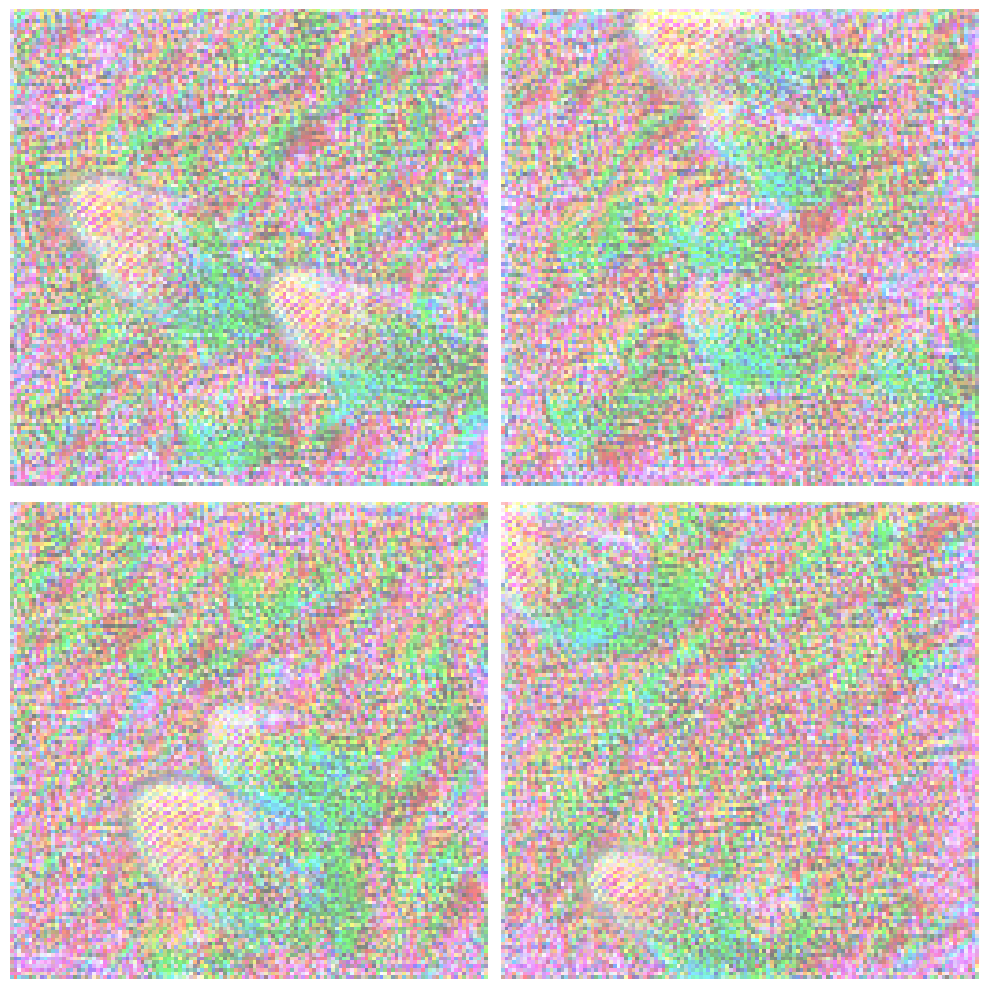

In [18]:


# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(latents):
        # Convert to numpy and transpose from CxHxW to HxWxC
        # img = latents[idx].permute(1, 2, 0).numpy()
        img = latents[idx].numpy()
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

100%|██████████| 50/50 [00:01<00:00, 49.71it/s]


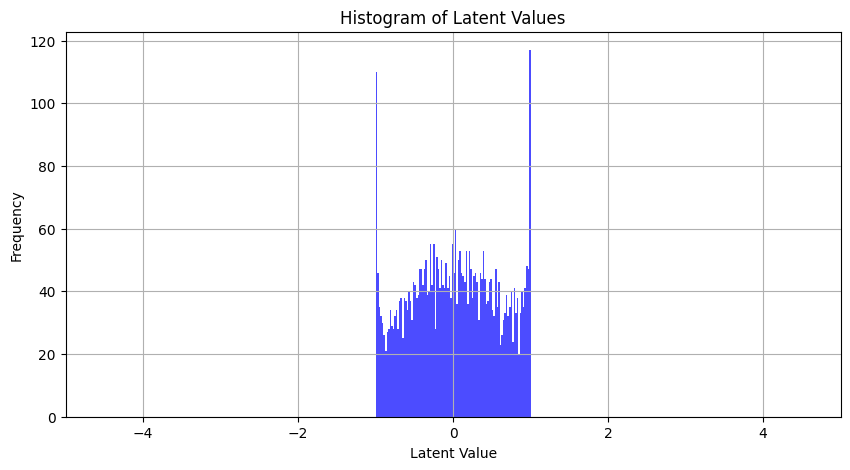

Latents_vae shape: torch.Size([4, 4, 16, 16]) Latents_vae min: -1.0 Latents_vae max: 1.0 datatype: torch.float32


In [43]:
config_path = "/media/aris/Data/master2025dev/aris_master/scripts/config_vae.json"
config = UNet2DModel.load_config(config_path)
model = UNet2DModel.from_config(config["model"])
num_classes = config["model"]["num_class_embeds"]

pipeline = Pipeline(
    unet=model,
    scheduler=scheduler,
)
pipeline.to("cuda")
generator = torch.Generator(device=pipeline.device).manual_seed(0)

batch_size = 4
interence_steps = 50
with torch.no_grad():
    latents_vae = pipeline(
        generator=generator,
        batch_size=batch_size,
        num_inference_steps=interence_steps,
        output_type="latent",
        return_dict=False
    )[0]
    
    
# ------------------------- PLOT HISTOGAM OF LATENTS ------------------------- #
import matplotlib.pyplot as plt
import numpy as np
# Flatten the latents to 1D
latents_flat = latents_vae.flatten().cpu().numpy()
# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(latents_flat, bins=100, color='blue', alpha=0.7)
plt.title('Histogram of Latent Values')
plt.xlabel('Latent Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.xlim(-5, 5)  # Set x-axis limits to focus on the range of interest
plt.show()

print("Latents_vae shape:", latents_vae.shape, "Latents_vae min:", latents_vae.min().item(), "Latents_vae max:", latents_vae.max().item(), "datatype:", latents_vae.dtype)

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

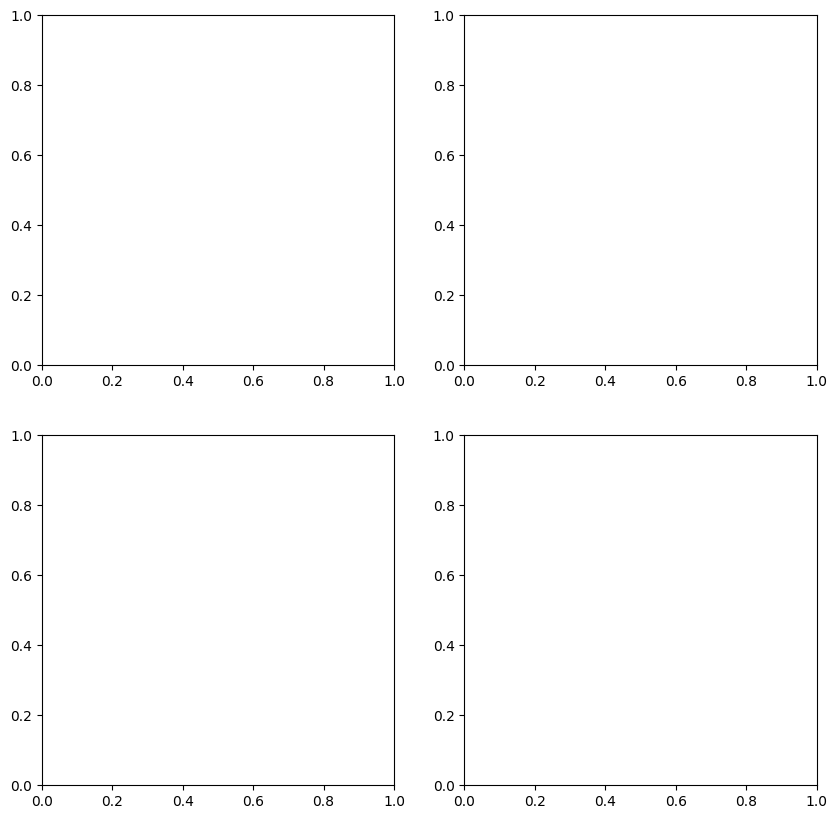

In [44]:
# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(latents_vae):
        # Convert to numpy and transpose from CxHxW to HxWxC
        # img = latents[idx].permute(1, 2, 0).numpy()
        img = latents_vae[idx].numpy()
        # clip to 3 channels
        img = img[:, :, :3]
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [48]:
#Run through VAE
latents_vae_permuted = latents_vae/vae.config.scaling_factor/vae.config.scaling_factor
print("Latents shape after permute:", latents_vae_permuted.shape, "Latents min:", latents_vae_permuted.min().item(), "Latents max:", latents_vae_permuted.max().item(), "datatype:", latents_vae_permuted.dtype)
images = vae.decode(latents_vae_permuted.to(vae.device), return_dict=False)[0]
print("Decoded images shape:", images.shape, "Decoded images min:", images.min().item(), "Decoded images max:", images.max().item(), "Decoded images dtype:", images.dtype)


Latents shape after permute: torch.Size([4, 4, 16, 16]) Latents min: -30.139888763427734 Latents max: 30.139888763427734 datatype: torch.float32
Decoded images shape: torch.Size([4, 3, 128, 128]) Decoded images min: -3.179774761199951 Decoded images max: 2.8948042392730713 Decoded images dtype: torch.float32


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8807833..2.4283319].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0399258..2.4517663].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.1797748..2.5681965].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.7714434..2.8948042].


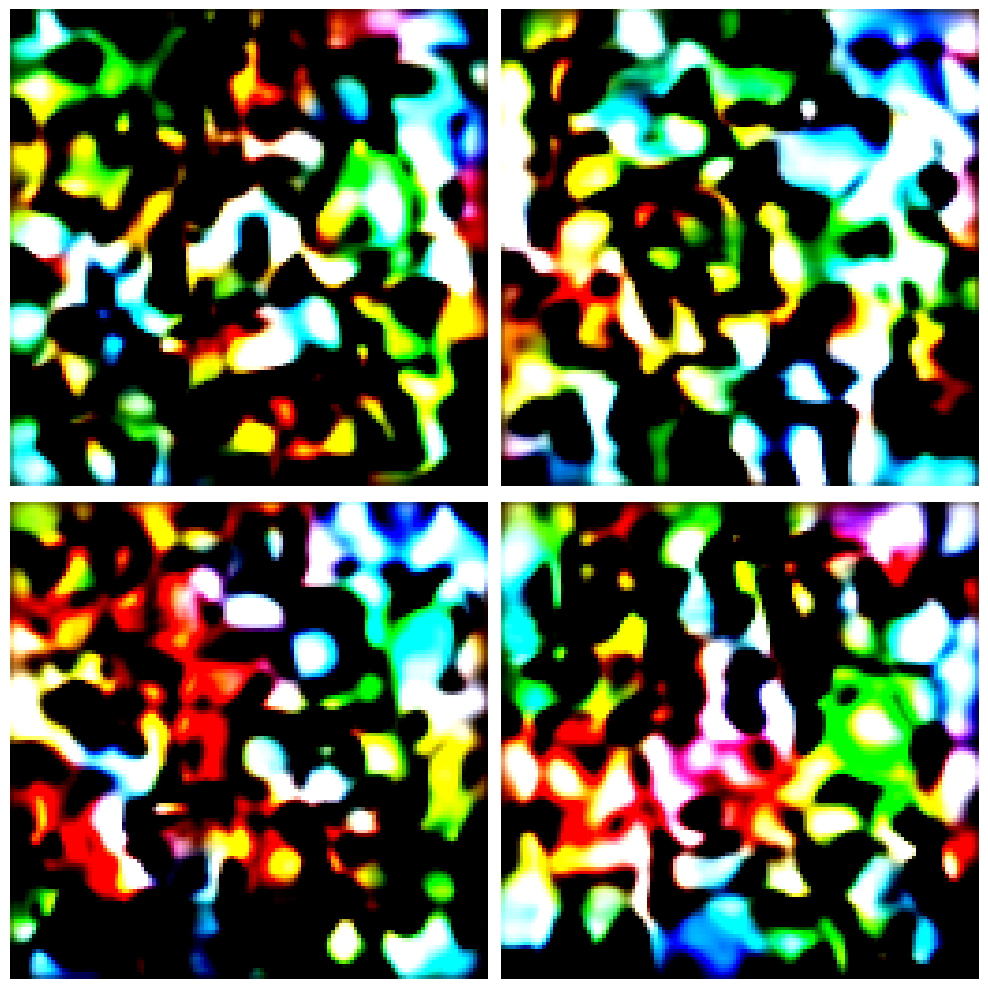

In [46]:
# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(images):
        # Convert to numpy and transpose from CxHxW to HxWxC
        # img = latents[idx].permute(1, 2, 0).numpy()
        img = images[idx].detach().cpu().numpy()
        # permute from CxHxW to HxWxC
        img = np.transpose(img, (1, 2, 0))
        # clip to 3 channels
        img = img[:, :, :3]
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

## Unet2DConditionModel
Following code attempts to create a Unet2DConditionModel and apply it

In [10]:
# from diffusers import UNet2DConditionModel
# local_model_path = os.path.join(os.getcwd(), "models/UNet/runwayml-stable-diffusion-v1-5")
# unet = UNet2DConditionModel.from_pretrained(local_model_path)

# unet.to(device)
# print("UNet model loaded successfully.")
# #print model config
# print("Model configuration:", unet.config)


# #Map image to latents
# latents = vae.encode(image)

# print("Latents shape:", latents.latent_dist.sample().shape)

# output_latents = unet(latents.latent_dist.sample(), timestep=10, encoder_hidden_states=torch.randn(1, 77, 768).to(device))
# print("Output latents shape:", output_latents.sample.shape)

In [11]:
# from diffusers import UNet2DModel

# path = "/media/aris/Data/master2025dev/aris_master/training/07-02_2-class-conditioning-wood-plastic_128/unet/config.json"
# config = UNet2DModel.load_config(path)
# print("UNet configuration:", config)
# model = UNet2DModel.from_config(config)
# print("UNet model loaded successfully.")



In [ ]:
import torch

## optimizer and scheduler debugging
scheduler_path = "/media/aris/Data/master2025dev/aris_master/training/02-17_VAE_128/checkpoint-90000/scheduler.bin"
optimizer_path = "/media/aris/Data/master2025dev/aris_master/training/02-17_VAE_128/checkpoint-90000/optimizer.bin"

scheduler_state = torch.load(scheduler_path)
# optimizer_state = torch.load(optimizer_path)

print("Scheduler state keys:", scheduler_state.keys())
print("Scheduler state:", scheduler_state)
# print("\nOptimizer state keys:", optimizer_state.keys())
# print("Optimizer state:", optimizer_state)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR

Scheduler state keys: dict_keys(['base_lrs', 'last_epoch', '_step_count', '_is_initial', '_get_lr_called_within_step', '_last_lr', 'lr_lambdas'])
Scheduler state: {'base_lrs': [0.000141], 'last_epoch': 90000, '_step_count': 90001, '_is_initial': False, '_get_lr_called_within_step': False, '_last_lr': [1.368813352462383e-06], 'lr_lambdas': [None]}

Optimizer state keys: dict_keys(['state', 'param_groups'])
Optimizer state: {'state': {0: {'step': tensor(90000.), 'exp_avg': tensor([[[[-3.2172e-06, -1.7560e-05,  1.5717e-05],
          [-1.1700e-05,  1.3440e-05,  3.0507e-05],
          [ 5.0676e-06,  2.0371e-05,  1.5456e-05]],

         [[ 2.5809e-05,  1.6467e-05, -1.2054e-05],
          [-1.8423e-05, -1.7556e-05, -2.4620e-05],
          [-2.7824e-06, -1.6382e-05,  2.1295e-06]],

         [[-1.8799e-05, -3.0801e-05, -1.0770e-05],
          [ 4.3529e-05, -9.3116e-06,  6.4851e-06],
          [ 2.7828e-05, -3.4701e-06, -9.0306e-06]],

         [[ 1.4893e-05,  3.9484e-06, -3.8458e-06],
        